In [1]:
from option import args
import torch
import utility
import data
import utils
import model
import loss
from trainer import Trainer
import os
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

np.random.seed(args.seed)
ids = utils.get_ids()
# ids.sort()
# total_vols = args.no_vols+args.test_vols
ids.sort()
# ids = ids[:total_vols]
# ids = np.random.choice(ids,total_vols,replace = False)
print(ids)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
args.thres = 0.8

In [3]:
checkpoint = utility.checkpoint(args)       ## setting the log and the train information
if checkpoint.ok:
    loader = data.Data(args,ids= ids)

Loading Done


## Histogram Analysis

In [4]:
bins = np.arange(0,1.01,0.01)
total_c_lr = np.zeros(0)
total_c_hr = np.zeros(0)

In [5]:
%matplotlib inline

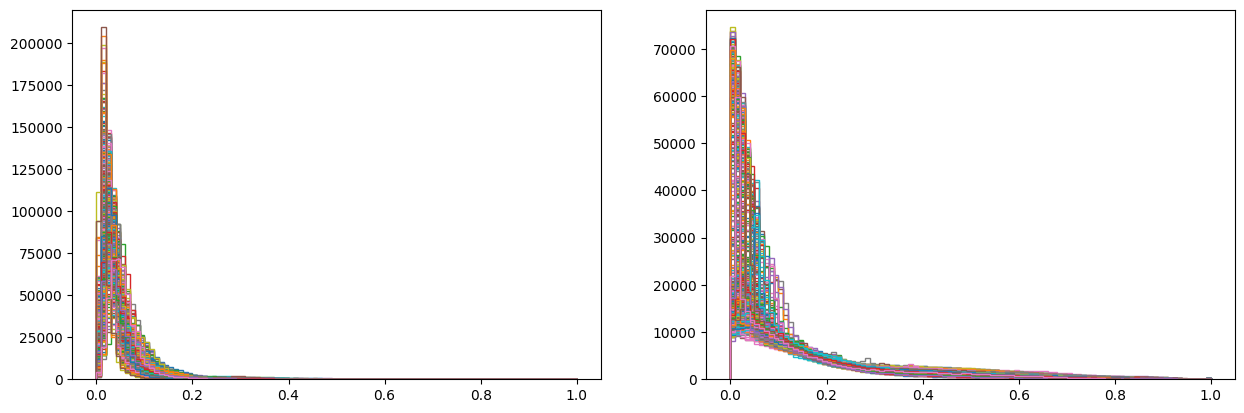

In [6]:
fig,ax = plt.subplots(1,2)
# pbar = tqdm(total = len(loader.testing_data))
fig.set_figwidth(15)
for batch, (lr,hr,scale,rel_coor) in enumerate(loader.training_data):
    lr = np.asarray(lr).squeeze()
    c,b = np.histogram(lr[lr>0],bins)
    if(len(total_c_lr) == 0):
        total_c_lr = c
    else:
        total_c_lr +=c
    ax[0].stairs(c, b)
    
    hr = np.asarray(hr).squeeze()
    c,b = np.histogram(hr[hr>0],bins)
    if(len(total_c_hr) == 0):
        total_c_hr = c
    else:
        total_c_hr +=c
    ax[1].stairs(c, b)
    



In [10]:
import scipy
temp_lr = scipy.stats.rv_histogram((total_c_lr,bins))
temp_hr = scipy.stats.rv_histogram((total_c_hr,bins))
X = np.linspace(0,1,100)

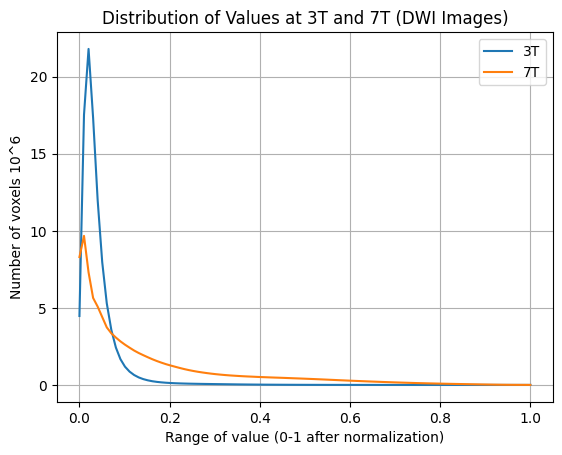

In [14]:
plt.title("Distribution of Values at 3T and 7T (DWI Images)")
plt.plot(X,temp_lr.pdf(X),label = "3T")
plt.plot(X,temp_hr.pdf(X),label = "7T")
plt.ylabel("Number of voxels 10^6")
plt.xlabel("Range of value (0-1 after normalization)")
plt.legend()
plt.grid()
plt.savefig("Distribution of value")

In [16]:
bins = np.arange(0,1.01,0.01)
total_c_lr = np.zeros(0)
total_c_hr = np.zeros(0)
total_out_lr = np.zeros(0)
total_out_hr = np.zeros(0)

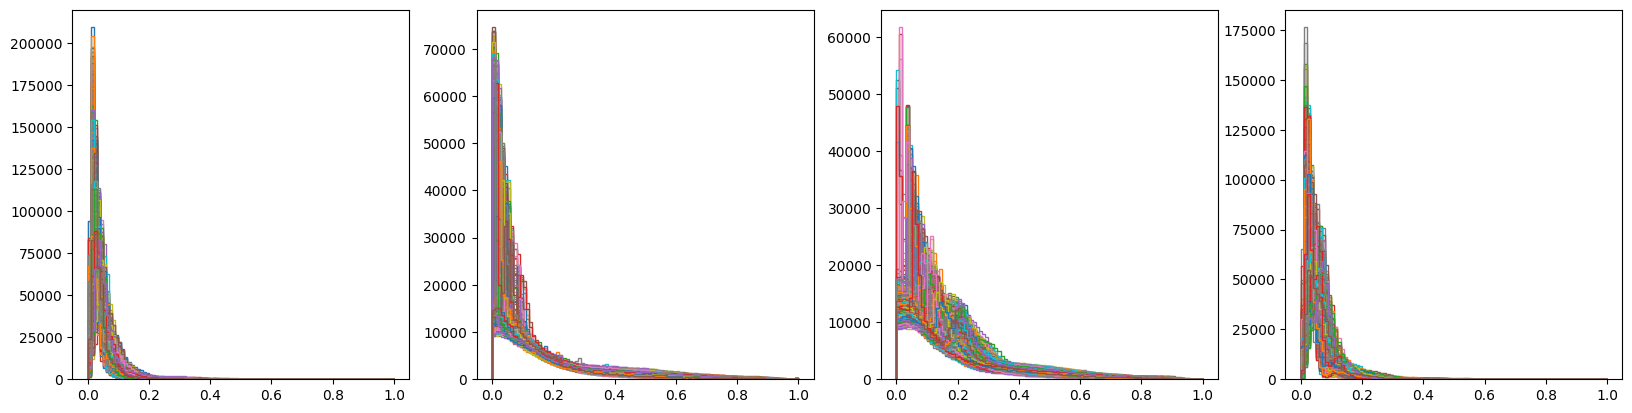

In [17]:
fig,ax = plt.subplots(1,4)

fig.set_figwidth(20)
for batch, (lr,hr,scale,rel_coor,out,idx,out_lr) in enumerate(loader.testing_data):
    lr = np.asarray(lr).squeeze()
    c,b = np.histogram(lr[lr>0],bins)
    if(len(total_c_lr) == 0):
        total_c_lr = c
    else:
        total_c_lr +=c
    ax[0].stairs(c, b)
    
    hr = np.asarray(hr).squeeze()
    c,b = np.histogram(hr[hr>0],bins)
    if(len(total_c_hr) == 0):
        total_c_hr = c
    else:
        total_c_hr +=c
    ax[1].stairs(c, b)
    
    out = np.asarray(out).squeeze()
    c,b = np.histogram(out[out>0],bins)
    if(len(total_out_hr) == 0):
        total_out_hr = c
    else:
        total_out_hr +=c
    ax[2].stairs(c, b)
    
    out_lr = np.asarray(out_lr).squeeze()
    c,b = np.histogram(out_lr[out_lr>0],bins)
    if(len(total_out_lr) == 0):
        total_out_lr = c
    else:
        total_out_lr +=c
    ax[3].stairs(c, b)
    

In [18]:
import scipy
temp_lr = scipy.stats.rv_histogram((total_c_lr,bins))
temp_hr = scipy.stats.rv_histogram((total_c_hr,bins))
temp_lr_out = scipy.stats.rv_histogram((total_out_lr,bins))
temp_hr_out = scipy.stats.rv_histogram((total_out_hr,bins))
X = np.linspace(0,1,100)

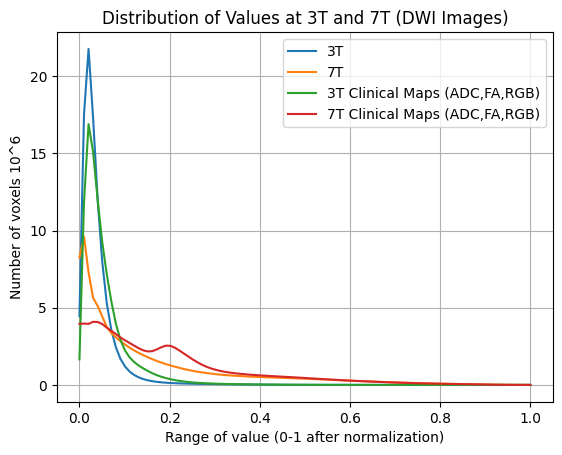

In [21]:
plt.title("Distribution of Values at 3T and 7T (DWI Images)")
plt.plot(X,temp_lr.pdf(X),label = "3T")
plt.plot(X,temp_hr.pdf(X),label = "7T")
plt.plot(X,temp_lr_out.pdf(X),label = "3T Clinical Maps (ADC,FA,RGB)")
plt.plot(X,temp_hr_out.pdf(X),label = "7T Clinical Maps (ADC,FA,RGB)")
plt.ylabel("Number of voxels 10^6")
plt.xlabel("Range of value (0-1 after normalization)")
plt.legend()
plt.grid()
plt.savefig("Distribution of value")

In [26]:
max_min_lr = {}
max_min_hr = {}
max_min_lr_out = {}
max_min_hr_out = {}

In [54]:
import pickle 

with open('max_min_lr.pkl', 'wb') as f:
    pickle.dump(max_min_lr, f)
    
with open('max_min_hr.pkl', 'wb') as f:
    pickle.dump(max_min_hr, f)
    
with open('max_min_lr_out.pkl', 'wb') as f:
    pickle.dump(max_min_lr_out, f)
    
with open('max_min_hr_out.pkl', 'wb') as f:
    pickle.dump(max_min_hr_out, f)
        

In [55]:

with open('max_min_lr.pkl', 'rb') as f:
    max_min_lr = pickle.load(f)
    
with open('max_min_hr.pkl', 'rb') as f:
    max_min_hr = pickle.load(f)
    
with open('max_min_lr_out.pkl', 'rb') as f:
    max_min_lr_out = pickle.load(f)
    
with open('max_min_hr_out.pkl', 'rb') as f:
    max_min_hr_out = pickle.load(f)